In [1]:
%%javascript
IPython.OutputArea.prototype._should_scroll = function(lines) return false;

<IPython.core.display.Javascript object>

In [ ]:
import dataset, plots
import pandas as pd

sp500_components: pd.DataFrame = dataset.SP500.load_historical()

### Połączenie danych z Yahoo Finance i EODHD

In [ ]:
yf_data: dict[str, pd.DataFrame] = dataset.YahooFinance.load()
eodhd_data: dict[str, pd.DataFrame] = dataset.EODHD.load()

merged_data: dict[str, pd.DataFrame] = dataset.merge_price_data(
    primary_data=eodhd_data,
    supplemental_data=yf_data,
)

dataset.save_merged_data(merged_data)

Saved Adj_Close.csv (24792 rows x 1200 columns)
Saved Close.csv (24792 rows x 1200 columns)
Saved Dividends.csv (24779 rows x 825 columns)
Saved High.csv (24792 rows x 1200 columns)
Saved Low.csv (24792 rows x 1200 columns)
Saved Open.csv (24792 rows x 1200 columns)
Saved Stock_Splits.csv (24779 rows x 825 columns)
Saved Volume.csv (24792 rows x 1200 columns)


Po połączeniu danych z YahooFinance i EODHD wyniki analizy pokrycia nie wykazują różnicy. Oznacza to, że tych danych, których nie ma w EODHD, nie ma również w danych z YahooFinance.

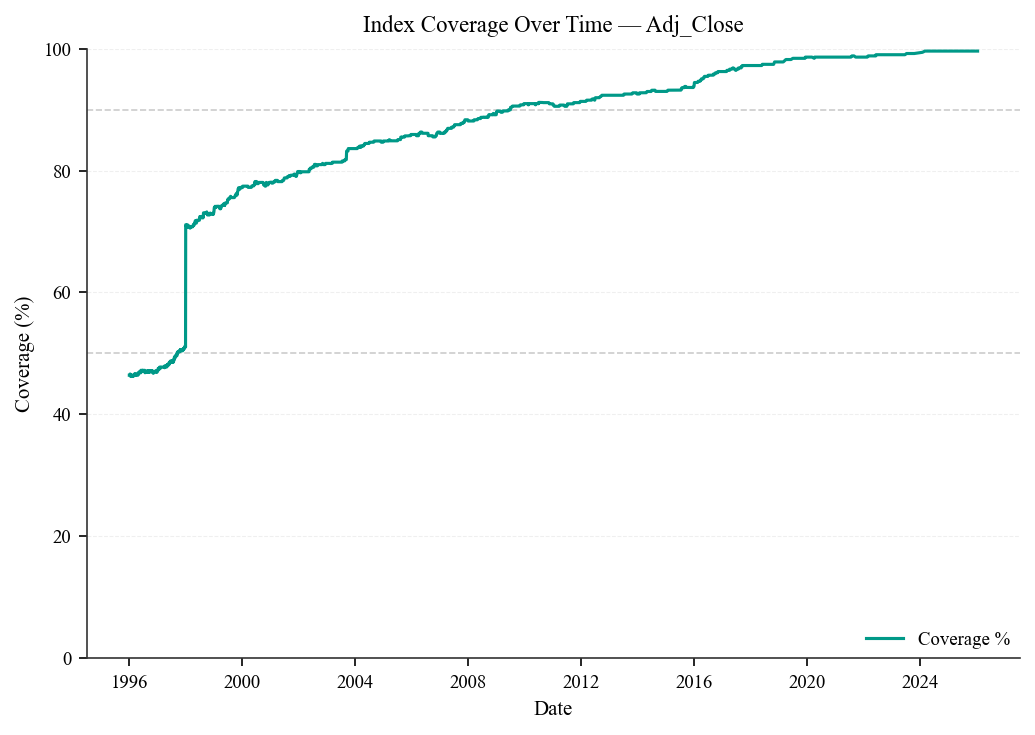

Missing ticker coverage periods:
- AAL:
  missing from 1996-01-02 to 1997-01-13
- AAMRQ:
  missing from 1996-01-02 to 2003-03-10
- ABI:
  missing from 1996-01-02 to 2008-11-20
- ABKFQ:
  missing from 2000-12-11 to 2008-06-10
- ABS:
  missing from 1996-01-02 to 1997-12-29
- ABX:
  missing from 1996-01-02 to 2002-07-18
- ACKH:
  missing from 1996-01-02 to 1997-12-29
- ACV:
  missing from 1996-01-02 to 2006-11-16
- ADCT:
  missing from 1999-08-02 to 2007-06-26
- ADT:
  missing from 2012-10-02 to 2016-04-28
- AET:
  missing from 1996-01-02 to 1997-12-29
- AFS.A:
  missing from 1998-04-08 to 2000-11-29
- AGC:
  missing from 1996-01-02 to 2001-08-20
- AHM:
  missing from 1996-01-02 to 1997-12-29
- AL:
  missing from 1996-01-02 to 2002-07-18
- ALTR:
  missing from 2000-04-18 to 2015-12-21
- AM:
  missing from 1996-01-02 to 2004-04-30
- AMH:
  missing from 1996-01-02 to 1997-09-08
- AMP:
  missing from 1996-01-02 to 1999-03-30
- ANDW:
  missing from 1996-01-02 to 1997-12-29
- ANRZQ:
  missing 

,available,missing,not_downloaded,total,coverage_pct
count,2705.00000000,2705.00000000,2705.00000000,2705.00000000,2705.00000000
mean,419.06469501,77.68465804,0.00000000,496.74935305,84.24338828
std,68.44197451,63.92203558,0.00000000,5.16624733,13.13484907
min,225.00000000,2.00000000,0.00000000,487.00000000,46.20123203
25%,391.00000000,36.00000000,0.00000000,494.00000000,78.98989899
50%,438.00000000,59.00000000,0.00000000,497.00000000,88.12877264
75%,461.00000000,104.00000000,0.00000000,499.00000000,92.75653924
max,502.00000000,262.00000000,0.00000000,507.00000000,99.60317460


,available,missing,not_downloaded,total,coverage_pct
1996-01-02,226,261,0,487,46.40657084
1996-01-03,226,261,0,487,46.40657084
2025-12-22,501,2,0,503,99.60238569
2026-01-14,501,2,0,503,99.60238569


In [ ]:
coverage_df: pd.DataFrame = plots.coverage_over_time(
    price_data=merged_data,
    components=sp500_components,
    filename="21-merged-coverage-over-time.png"
)

plots.summarize_df(coverage_df)

### Uzupełnienie brakujących danych

Aby zminimalizować wpływ błędu przeżywalności istotne jest uwzględnienie zwrotów z akcji spółek, których danych nie ma w pobranych danych. Błąd przeżywalności zazwyczaj powoduje zawyżenie stóp zwrotu portfeli, co prowadzi do nierealistycznych wyników, a tym samym błędnych wniosków. Aby zminimalizować jego wpływ można zastosować 2 rozwiązania:

1. Brać pod uwagę tylko okno czasowe powyżej dobranego poziomu pokrycia indeksu. W tym przypadku rozsądnym byłoby ucięcie w okolicach 70% pokrycia od 1998 roku. Te rozwiązanie co prawda zmniejsza możliwy do testowania okres, ale to tylko 2 lata, a pozwoli na wyeliminowanie okresu, w którym więcej spółek miało dane, niż w tym kiedy nie miało.
2. Zaimputować brakujące dane na podstawie stóp zwrotu z indeksu i cen akcji spółek z pokryciem.

W praktyce warto wykorzystać oba te rozwiązania